# Direct N-Body Gravity Simulation

This notebook demonstrates the **brute-force** O(N²) gravitational simulation
using `direct_nbody_step()` from the `barnes_hut` library.

For large N, use the Barnes-Hut tree-based approach instead (see the
Barnes-Hut examples notebook).

---

In [2]:
from barnes_hut import Point, direct_nbody_step, make_solar_system
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
%matplotlib inline

## 1. Simple System: Star + Two Planets

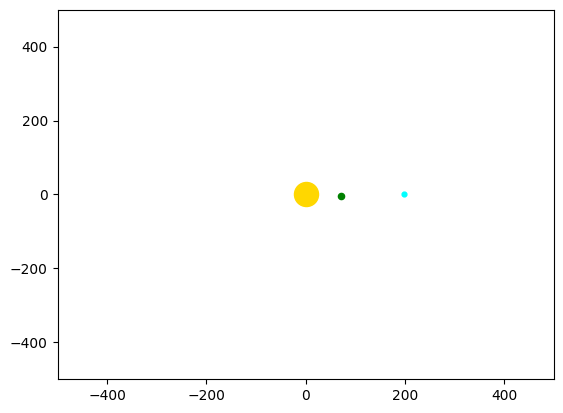

In [3]:
# Create particles
star    = Point(x=0, y=0,   mass=100000, vx=0,  vy=0)
planet1 = Point(x=72, y=0,  mass=950,    vx=0,  vy=-30)
planet2 = Point(x=200, y=0, mass=500,    vx=-5, vy=12)
particles = [star, planet1, planet2]

colors = ["gold", "green", "cyan"]
sizes  = [300, 20, 12]

for t in range(3000):
    direct_nbody_step(particles, dt=0.05, G=1.0, eps=1.0)
    for i, p in enumerate(particles):
        plt.scatter(p.x, p.y, c=colors[i], s=sizes[i])
    plt.xlim(-500, 500)
    plt.ylim(-500, 500)
    plt.show()
    clear_output(wait=True)

## 2. Star + Three Planets

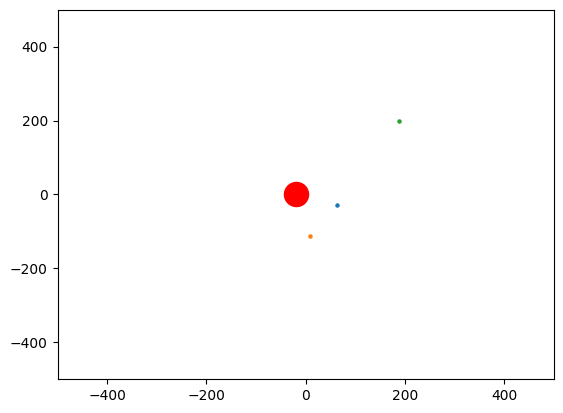

In [4]:
star    = Point(x=-20, y=0, mass=100000, vx=0,  vy=0)
p1      = Point(x=72,  y=0, mass=150,    vx=0,  vy=-30)
p2      = Point(x=200, y=0, mass=300,    vx=-5, vy=12)
p3      = Point(x=312, y=0, mass=200,    vx=-1, vy=15)
particles = [star, p1, p2, p3]

for t in range(30):
    direct_nbody_step(particles, dt=0.5, G=1.0, eps=1.0)
    for i, p in enumerate(particles):
        color = "red" if p.mass == max(q.mass for q in particles) else None
        plt.scatter(p.x, p.y, s=max(5, p.mass * 0.003), c=color)
    plt.xlim(-500, 500)
    plt.ylim(-500, 500)
    plt.show()
    clear_output(wait=True)

## 3. Solar System (Realistic)

Using real masses and orbital velocities in SI units:

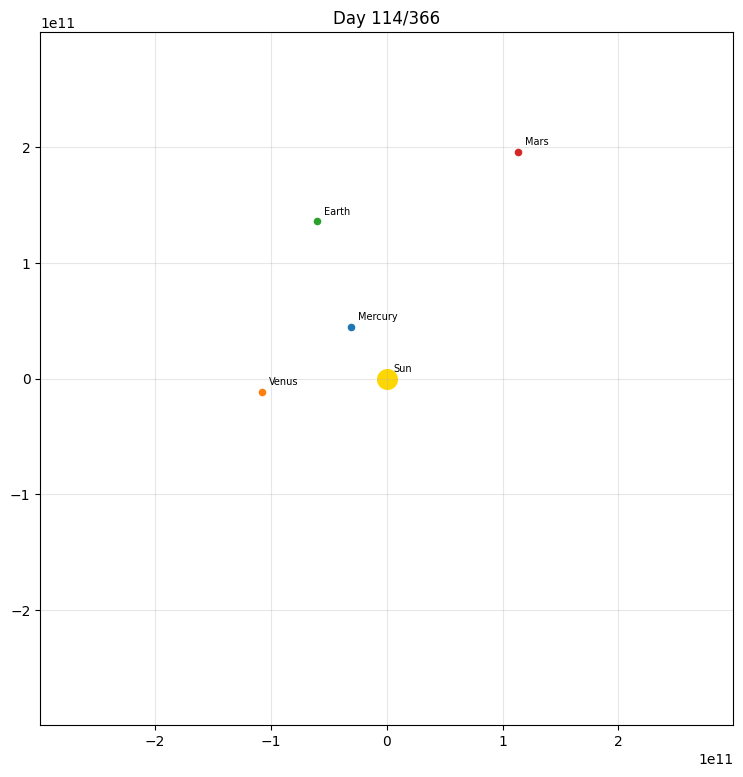

In [ ]:
particles = make_solar_system()

# Solar system constants
AU = 1.496e11
G_SI = 6.674e-11
names = ["Sun", "Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune"]
days_per_frame = 1
max_time = 366
limit = 2 * AU

for t in range(max_time):
    direct_nbody_step(particles, dt=days_per_frame * 86400, G=G_SI, eps=1e8)
    fig, ax = plt.subplots(figsize=(9, 9))
    for i, p in enumerate(particles):
        s = 200 if i == 0 else 20
        c = "gold" if i == 0 else None
        ax.scatter(p.x, p.y, s=s, c=c)
        ax.annotate(names[i], (p.x, p.y), fontsize=7,
                    xytext=(5, 5), textcoords="offset points")
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect("equal")
    ax.set_title(f"Day {t+1}/{max_time}")
    ax.grid(True, alpha=0.3)
    plt.show()
    clear_output(wait=True)